# Análisis de Datos: ENDIREH 2021

**Almacenes y Minería de Datos — Práctica 3**

Se dan los resultados del análisis, con datos de los scripts de `src/`.

| Script | Uso |
|---|---|
| `src/cleaning/limpieza.py` | Preprocesamiento: duplicados, tipos, códigos de no respuesta |
| `src/visualization/eda.py` | Medidas de localización y variabilidad |
| `src/visualization/graficas.py` | Construcción de graficas |

Importamos los datos de esos módulos en lugar de repetir cálculos, teniendo asi una sola fuente
de informacion.

> **Antes de ejecutar:** correr `python src/cleaning/limpieza.py` desde la raíz
> del proyecto para generar `data/data-processed/endireh_limpio.parquet`.

## 1. Carga de datos

Cargamos el dataset ya preprocesado. El archivo crudo no se toca: para eso es `limpieza.py`.

In [3]:
# Importa polars como pl
import polars as pl
# Importa numpy como np
import numpy as np
# Importamos modulos de Python para manipular rutas de archivos
import sys
from pathlib import Path

# Agrega la raíz del proyecto al path para importar config/ y src/.
# Se resuelve de forma absoluta así funciona desde donde sea.
RAIZ = Path.cwd()
if not (RAIZ / "config").exists():
    RAIZ = RAIZ.parent
sys.path.append(str(RAIZ))

# Importa la ruta hacia data/data-processed/ definida en config/rutas.py
from config.rutas import RUTA_DATA_PROCESSED

# Cargar dataset parquet procesado con Polars
df = pl.read_parquet(RUTA_DATA_PROCESSED / "endireh_limpio.parquet")

# Imprime filas y columnas para verificar que se importó correctamente
print("Dimensiones del dataset:", df.shape)
# Suma de factores de expansión: debe rondar los 50 millones de mujeres de 15+
print(f"Población representada: {df['factor_expansion'].sum():,.0f} mujeres de 15 años")

# Crea una tabla con las primeras filas para verificar el formato esperado
df.head(3)

Dimensiones del dataset: (105752, 25)
Población representada: 49,144,897 mujeres de 15 años


cve_entidad,nom_entidad,cve_municipio,nom_municipio,edad_primer_union,num_hijos,nivel_escolaridad,estado_civil_id,estado_civil_desc,estrato_socioeconomico,pareja_trabaja_id,pareja_trabaja_desc,ingreso_pareja,dinero_propio_id,dinero_propio_desc,apoyo_gobierno_id,apoyo_gobierno_desc,tiene_ahorros_id,tiene_ahorros_desc,propietaria_vivienda_id,propietaria_vivienda_desc,sufrio_violencia_pareja,factor_expansion,anio_encuesta,ingreso_pareja_imputado
i8,cat,i16,cat,f64,f64,cat,i8,cat,i8,i8,cat,f64,i8,cat,i8,cat,i8,cat,i8,cat,i8,f64,i16,bool
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",null,3.0,"""A1""",5,"""Casada""",4,1,"""Sí""",10000.0,1,"""Sí""",2,"""No""",2,"""No""",1,"""Sí""",0,113.0,2021,false
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",null,3.0,"""A1""",5,"""Casada""",4,2,"""No""",null,2,"""No""",1,"""Sí""",2,"""No""",1,"""Sí""",1,113.0,2021,false
1,"""AGUASCALIENTES""",1,"""AGUASCALIENTES""",13.0,3.0,"""B2""",4,"""Viuda""",4,2,"""No""",null,2,"""No""",1,"""Sí""",2,"""No""",2,"""No""",0,227.0,2021,false


## 2. Datos tras el preprocesamiento

`limpieza.py` ejecuta, Carga en UTF-8 → Valida columnas →
reparación de encoding → códigos de no respuesta a null → conversión de tipos →
elimina duplicados → imputación.

Lo que la ejecución reporta sobre el archivo crudo:

| Paso | Resultado |
|---|---|
| Filas crudas | 110,127 |
| Encoding | 409 valores distintos en 9 columnas |
| Códigos de no respuesta | 883 en `edad_primer_union` (98, 99) y 4,058 en `ingreso_pareja` (999997/98/99) |
| Duplicados por eliminar | 4,375 filas idénticas |
| Imputación | 4,028 valores de `ingreso_pareja` con la mediana por estrato |
| Filas finales | 105,752 |

### Soluciones a datos null

Los nulls indican distinta informacion, debemos aplicar distintos criterios, de este
modo evitamos informacion falsa

1. **Estructural (no aplica).** `ingreso_pareja` es null si 
   `pareja_trabaja = No`. Son 56,894 casos y no se imputan: un ingreso
   inventado agrega información erronea ya que la pareja no trabaja.
2. **No respuesta.** La pregunta no se contestaba,
   Son 4,028 y sí se imputan, con la mediana por
   `estrato_socioeconomico`. Mediana y no media porque la distribución del
   ingreso está muy sesgada, el ingreso varía por el nivel socioeconómico del hogar.
4. **Por diseño del consolidado.** `edad_primer_union` solo tiene valor en las
   mujeres cuya unión terminó. Se conserva como null.

In [6]:
# Revisamos nulls en el dataset  limpio: cuantos quedan por
# columna y cuanto representan del total de filas.
nulos = (
    df.null_count()  # una fila con el conteo de nulos de cada columna
    # transpose la voltea para tener una fila por variable en vez de una columna
    .transpose(include_header=True, header_name="variable", column_names=["nulos"])
    .with_columns((100 * pl.col("nulos") / df.height).round(1).alias("pct"))
    .filter(pl.col("nulos") > 0)  # las columnas completas no aportan a la tabla
    .sort("nulos", descending=True)
)
print("Columnas con valores nulos tras preprocesamiento:")
print(nulos)

# Verificamos que el preprocesamiento haya funcionado
print(f"\nFilas duplicadas restantes: {df.height - df.unique().height}")
print(f"Entidades de ejemplo: {sorted(df['nom_entidad'].unique().to_list())[6:9]}")

Columnas con valores nulos tras preprocesamiento:
shape: (3, 3)
┌───────────────────┬───────┬──────┐
│ variable          ┆ nulos ┆ pct  │
│ ---               ┆ ---   ┆ ---  │
│ str               ┆ u32   ┆ f64  │
╞═══════════════════╪═══════╪══════╡
│ edad_primer_union ┆ 82090 ┆ 77.6 │
│ ingreso_pareja    ┆ 56894 ┆ 53.8 │
│ num_hijos         ┆ 19231 ┆ 18.2 │
└───────────────────┴───────┴──────┘

Filas duplicadas restantes: 0
Entidades de ejemplo: ['CIUDAD DE MÉXICO', 'COAHUILA DE ZARAGOZA', 'COLIMA']


## 3. Clasificación de variables (Paso 5)

La tabla distingue **subtipo**, no solo si la variable es cualitativa o
cuantitativa: nominal contra ordinal, discreta contra continua.

- **`edad_primer_union`**: el 60.2% de sus valores es menor a 10 y solo la tienen
  las mujeres cuya unión terminó (98% de viudas, 3% de casadas). Indicando que no puede
  ser una edad, lo tomamos como *años transcurridos desde que terminó la unión*.
- **`num_hijos`**: toma los valores 1, 2, 3 y 4, y el 2 aparece 2,115
  veces contra 36,019 del 3. No es un conteo de hijos, es un código.
- **`nivel_escolaridad`**: Categorizadas en `A1, A2, B1, B2, C1, C2`, no
  corresponden a ningún nivel educativo del catálogo del INEGI.

Vamos a describir estas variables por su comportamiento observado.

In [8]:
# Tabla de clasificación (Paso 5): cada diccionario es una fila.
# "Tipo de Dato" con el subtipo (nominal/ordinal, discreta/continua).
clasificacion = [
    # --- Cuantitativas ---
    {"Variable": "ingreso_pareja", "Tipo de Dato": "Cuantitativa continua",
     "Justificación": "Ingreso mensual en pesos, valores real en su rango."},
    {"Variable": "factor_expansion", "Tipo de Dato": "Cuantitativa continua",
     "Justificación": "Ponderador muestral: mujeres de la población que representa cada observación."},
    {"Variable": "edad_primer_union", "Tipo de Dato": "Cuantitativa discreta",
     "Justificación": "Años enteros, el 60.2% es menor a 10 y solo la tienen las uniones terminadas: se concluye que no es edad."},
    {"Variable": "num_hijos", "Tipo de Dato": "Cualitativa ordinal",
     "Justificación": "Solo toma valores 1-4 con distribución no monótona; se comporta como código, no como conteo."},

    # --- Cualitativas ordinales ---
    {"Variable": "estrato_socioeconomico", "Tipo de Dato": "Cualitativa ordinal",
     "Justificación": "Cuatro niveles jerárquicos (1 a 4); admite moda y mediana, no media."},
    {"Variable": "nivel_escolaridad", "Tipo de Dato": "Cualitativa ordinal",
     "Justificación": "Categorías A1-C2 aparentemente jerárquicas, pero no corresponden a niveles educativo de INEGI."},

    # --- Cualitativas nominales ---
    {"Variable": "nom_entidad", "Tipo de Dato": "Cualitativa nominal",
     "Justificación": "Las 32 entidades federativas; sin orden específico."},
    {"Variable": "nom_municipio", "Tipo de Dato": "Cualitativa nominal",
     "Justificación": "1,206 municipios; sin orden específico."},
    {"Variable": "estado_civil_desc", "Tipo de Dato": "Cualitativa nominal",
     "Justificación": "Estado conyugal: casada, soltera, divorciada, etc. Sin jerarquía."},

    # --- Cualitativas dicotómicas (nominales de dos categorías) ---
    {"Variable": "sufrio_violencia_pareja", "Tipo de Dato": "Cualitativa nominal dicotómica",
     "Justificación": "Indicador binario: 1 = reportó violencia, 0 = no reportó."},
    {"Variable": "pareja_trabaja_desc", "Tipo de Dato": "Cualitativa nominal dicotómica",
     "Justificación": "Sí / No. Determina si ingreso_pareja aplica."},
    {"Variable": "dinero_propio_desc", "Tipo de Dato": "Cualitativa nominal dicotómica",
     "Justificación": "Sí / No. Parte del bloque de autonomía económica."},
    {"Variable": "tiene_ahorros_desc", "Tipo de Dato": "Cualitativa nominal dicotómica",
     "Justificación": "Sí / No. Parte del bloque de autonomía económica."},
    {"Variable": "propietaria_vivienda_desc", "Tipo de Dato": "Cualitativa nominal dicotómica",
     "Justificación": "Sí / No. Parte del bloque de autonomía económica."},
    {"Variable": "apoyo_gobierno_desc", "Tipo de Dato": "Cualitativa nominal dicotómica",
     "Justificación": "Sí / No. Recepción de programas de ayuda."},
]

# Convierte la lista de diccionarios en DataFrame de Polars
df_clasificacion = pl.DataFrame(clasificacion)

# Configura polars para que no trunque el texto de las justificaciones
with pl.Config(fmt_str_lengths=110, tbl_rows=20, tbl_width_chars=190):
    print(df_clasificacion)

shape: (15, 3)
┌───────────────────────────┬────────────────────────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Variable                  ┆ Tipo de Dato                   ┆ Justificación                                                                                             │
│ ---                       ┆ ---                            ┆ ---                                                                                                       │
│ str                       ┆ str                            ┆ str                                                                                                       │
╞═══════════════════════════╪════════════════════════════════╪═══════════════════════════════════════════════════════════════════════════════════════════════════════════╡
│ ingreso_pareja            ┆ Cuantitativa continua          ┆ Ingreso mensual en pesos, valores real en su rango.                

## 4. Medidas de localización (Paso 6)

Las funciones provienen de `src/visualization/eda.py`. Para cada variable
cuantitativa se calculan media, mediana, moda, cuartiles y percentiles 10 y 90,
en versión simple y ponderada por el factor de expansión.

### Criterios de cálculo

**Cada variable se filtra por separado.** Al describir `edad_primer_union` se
descartan únicamente las filas con nulls. Este valor 
no puede depender del valor de otra columna
porque eso sesga la muestra afectando el resultado.

**No se recorta el rango de los valores.** Acotar el rango hasta que la cifra parezca razonable, 
en `edad_primer_union`, filtramos a un mínimo de 10 años deja fuera 14,239 de los 23,662 casos válidos.

La ponderación se aplica también a la mediana y a los cuantiles, no solo a la
media, ponderar una medida de tendencia central y dejar las demás sin ponderar
haría que las dos columnas de la tabla no fueran comparables entre sí. Como ni
polars ni numpy ofrecen cuantiles con pesos, lo implementamos con `eda.py`.

In [4]:
# Importamos las funciones de cálculo desde el script de EDA. El notebook
# muestra los resultados; el cálculo ocurre en src/visualization/eda.py.
from src.visualization.eda import seccion_localizacion

# Imprime media, mediana, moda, Q1, Q3, P10 y P90, simples y ponderadas, para
# cada variable cuantitativa, junto con el aviso de coherencia cuando aplica.
seccion_localizacion(df)


 PASO 6: MEDIDAS DE LOCALIZACION

La media ponderada usa factor_expansion. La mediana, los cuartiles y
los percentiles ponderados se calculan con una funcion propia, porque
ni polars ni numpy ofrecen cuantiles con pesos.

--- edad_primer_union
    n = 23,662 observaciones | poblacion estimada = 11,084,038 mujeres
    [!] AVISO: 14,239 valores (60.2%) son menores a 10. Una edad a la primera union no puede serlo.

    Medida         Sin ponderar      Ponderada
    ------------------------------------------
    Media                 10.03           9.70
    Mediana (Q2)           6.00           6.00
    Moda                   0.00           0.00
    Q1                     2.00           2.00
    Q3                    15.00          15.00
    P10                    0.00           0.00
    P90                   25.00          25.00

    Diferencia media ponderada - media simple: -0.33

--- num_hijos
    n = 86,521 observaciones | poblacion estimada = 36,688,742 mujeres
    [!] AVISO: solo 

## 5. Medidas de variabilidad (Paso 7)

Rango, varianza, desviación estándar, coeficiente de variación e IQR,
comparando el grupo que reportó violencia de pareja contra el que no.

El CV es la medida central de esta sección porque expresa la dispersión como
porcentaje de la media, lo que permite comparar grupos cuyas medias difieren.

Estas medidas van sin ponderar: describen la dispersión dentro
de cada grupo de la muestra.

In [9]:
from src.visualization.eda import seccion_variabilidad

# Compara rango, varianza, desviación, CV e IQR entre el total, el grupo que
# reportó violencia y el que no, para cada variable cuantitativa.
seccion_variabilidad(df)


 PASO 7: MEDIDAS DE VARIABILIDAD

Comparacion entre el grupo que reporto violencia de pareja y el que no.
Las medidas van sin ponderar: el CV compara dispersion relativa dentro
de cada grupo, no estima un total poblacional. Es una limitacion a
declarar en el reporte.

--- edad_primer_union
    Medida                   Total   Con violencia   Sin violencia
    ------------------------------------------------------------
    n                       23,662           8,467          15,195
    Media                    10.03           10.03           10.03
    Rango                    76.00           72.00           76.00
    Varianza                114.90          110.52          117.35
    Desv. estandar           10.72           10.51           10.83
    CV (%)                  106.86          104.86          107.96
    IQR                      13.00           13.00           13.00

    Razon de CV (con/sin): 0.97

--- num_hijos
    Medida                   Total   Con violencia   Sin vi

## 6. Visualizaciones

Las cinco graficas se construyen en `src/visualization/graficas.py` y se guardan
en `reports/figuras/`. 

In [11]:
# generar_graficas construye las cinco figuras; RUTA_FIGURAS es la carpeta
# donde las deja, definida a partir de config/rutas.py.
from src.visualization.graficas import generar_graficas, RUTA_FIGURAS
from IPython.display import Image, display

# Escribe los PNG en reports/figuras/, creando la carpeta si no existe.
generar_graficas()

[graficas] Dataset: 105,752 filas. Guardando en /home/luisf/proyecto-endireh-violencia/reports/figuras
[graficas] reports/figuras/01_distribucion_edad_primer_union.png
[graficas] reports/figuras/02_ingreso_por_violencia.png
[graficas] reports/figuras/03_prevalencia_por_entidad.png
[graficas] reports/figuras/04_prevalencia_por_estado_civil.png
[graficas] reports/figuras/05_escolaridad_muestra_vs_poblacion.png
[graficas] Listo: 5 figuras generadas.


### 6.1 Distribución de `edad_primer_union`

Picos en 10, 15, 20, 25 y 30. La franja sombreada cubre el 60.2% de los valores, todos por debajo
de 10 y por tanto imposibles como edad a la primera unión.

Ese patrón, junto con la distribución de los nulls la variable tiene valor en
el 98% de las viudas y en el 3% de las casadas, concluimos que apunta a la medicion del tiempo
transcurrido desde que la unión terminó.

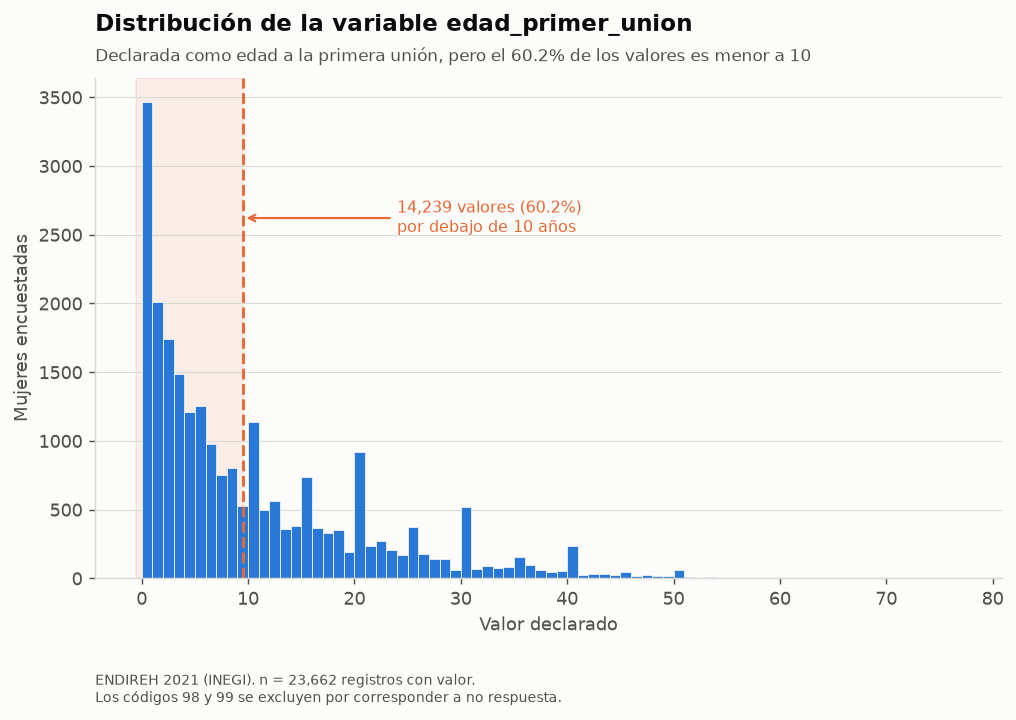

In [12]:
# Figura 1 generada, leyéndola desde reports/figuras/.
display(Image(filename=str(RUTA_FIGURAS / "01_distribucion_edad_primer_union.png")))

### 6.2 Dónde se separan los ingresos

Esta comparación es la que sostiene las respuestas a las preguntas 3 y 5 del cuestionario.

Las dos distribuciones son casi idénticas en la mitad baja: P10 de \$500 *en ambos grupos*, *mediana de* \$1,500 *contra* \$1,600 *y se separan en la mitad alta* (Q3 *de* \$3,500 *contra* \$5,000; P90 *de* \$8,000 *contra* \$10,000). Ahí está el origen del CV de 149% contra 195% de la sección anterior: la diferencia de dispersión proviene de la cola superior, no del centro.

Por eso la lectura precisa no es que las parejas violentas ganen menos, sino que entre las mujeres que reportaron violencia casi no hay parejas de ingresos altos.

> **Lectura ética.** No podemos concluir que el bajo ingreso cause violencia, un factor puede ser que las mujeres con parejas de ingresos altos **reporten** menos, no que sufran en menor cantidad.

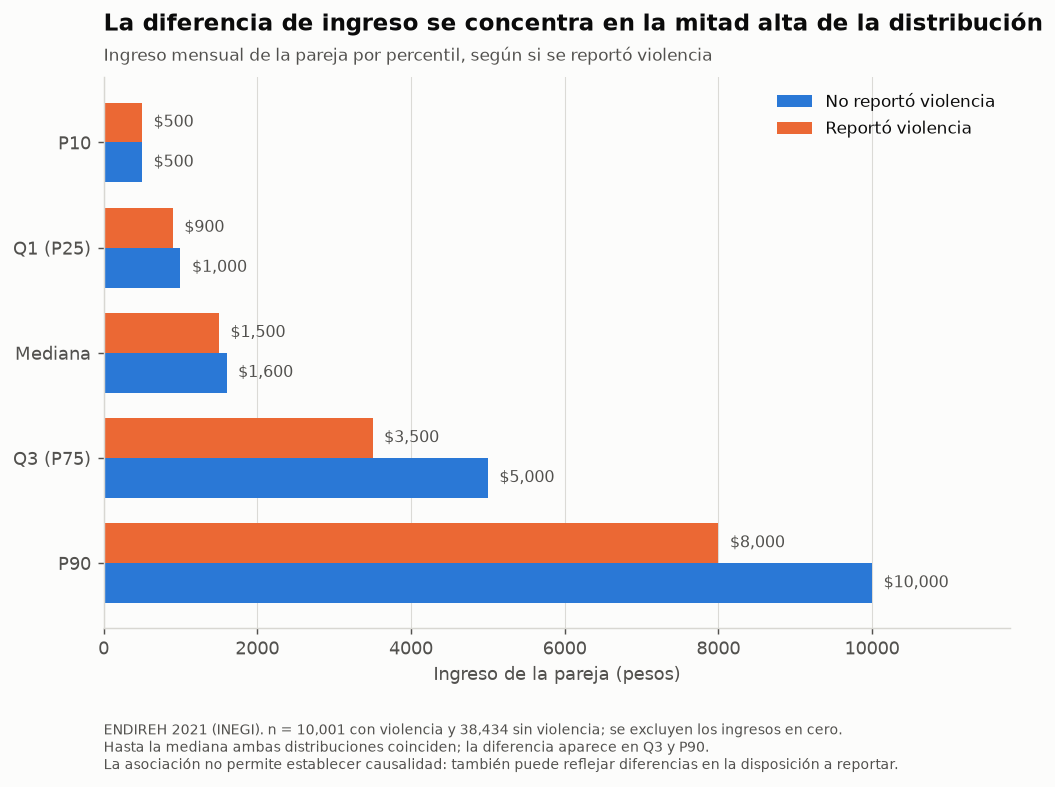

In [13]:
# figura 2 ya generada, leyéndola desde reports/figuras/.
display(Image(filename=str(RUTA_FIGURAS / "02_ingreso_por_violencia.png")))

### 6.3 y 6.4 Prevalencia por entidad y por estado conyugal

La prevalencia nacional ponderada es de **17.8%**. Entre entidades el rango va
de 11.2% a 23.0%, una variación moderada.

Por estado conyugal el contraste: las mujeres separadas (45.7%)
y divorciadas (44.4%) reportan cerca del triple que las casadas (14.1%).

> **Lectura ética.** A pesar de que no dice que separarse provoque violencia; lo contrario es al menos igual de probable, que motivo de la separación haya sido la violencia, La
> encuesta registra ambos hechos en un mismo momento, de modo que
> no permite establecer el orden entre ellos.
>
> Lo mismo aplica a las entidades: una prevalencia alta no describe un
> más violencia, debido a que puede reflejar mejores condiciones para que
> las mujeres reporten. Estas cifras miden lo reportado en la
> encuesta, no la ocurrencia de que ocurra.

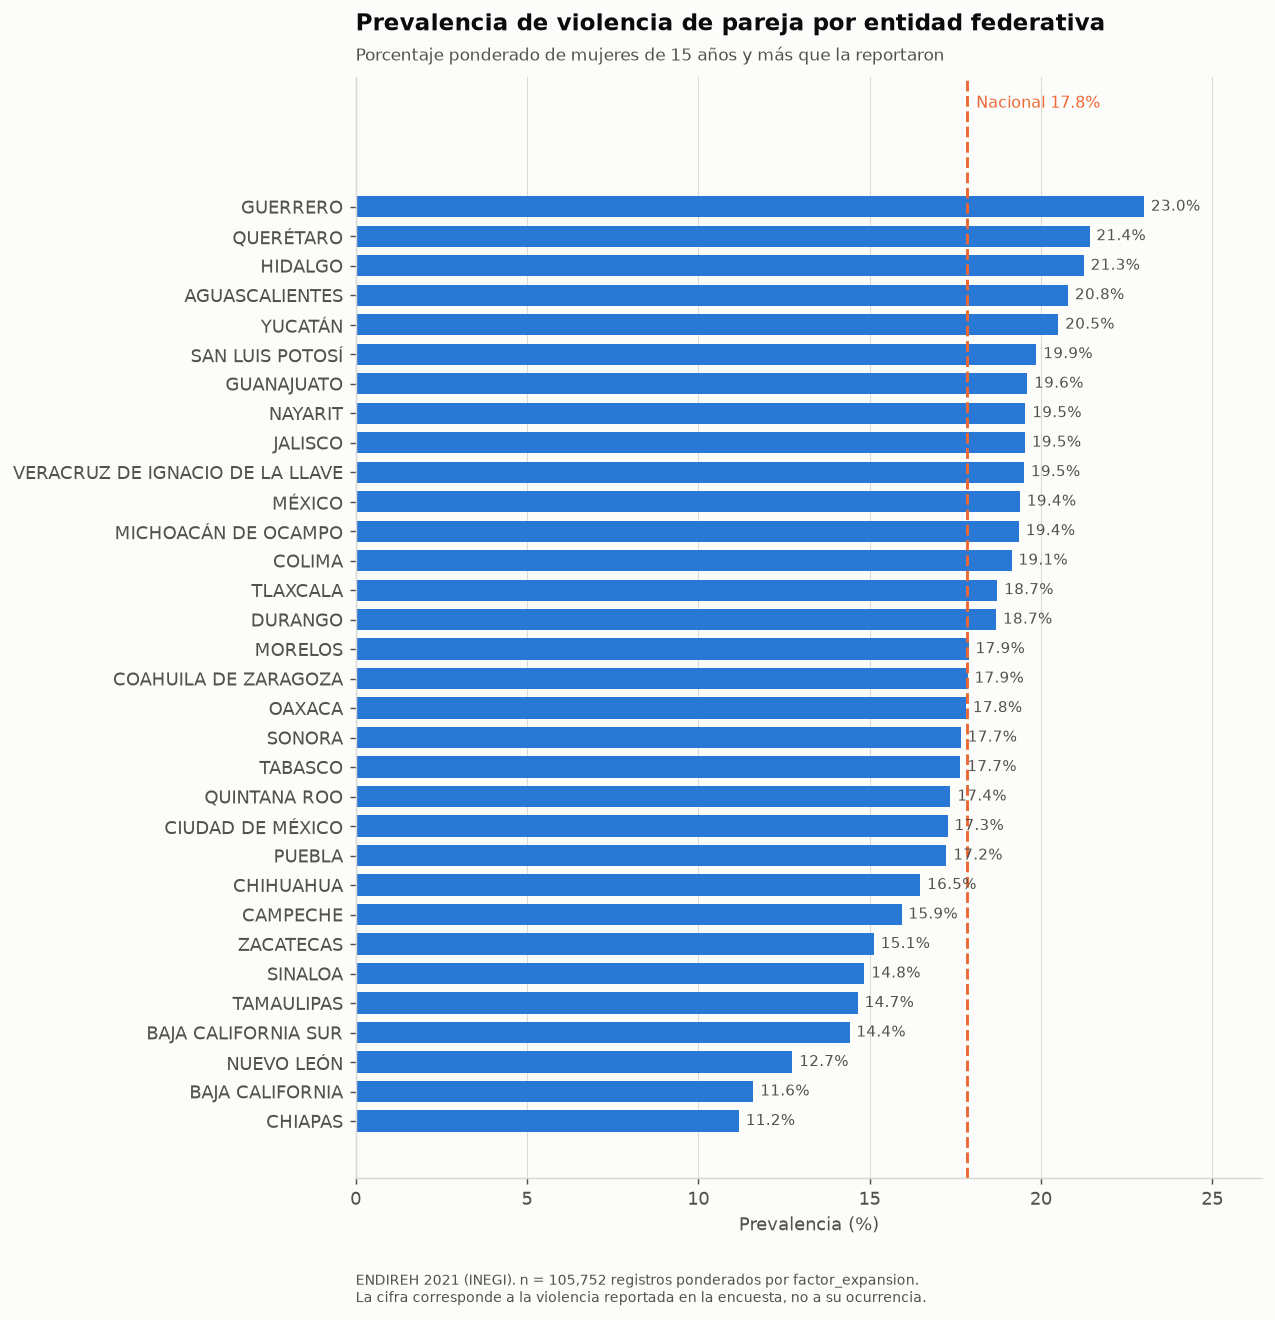

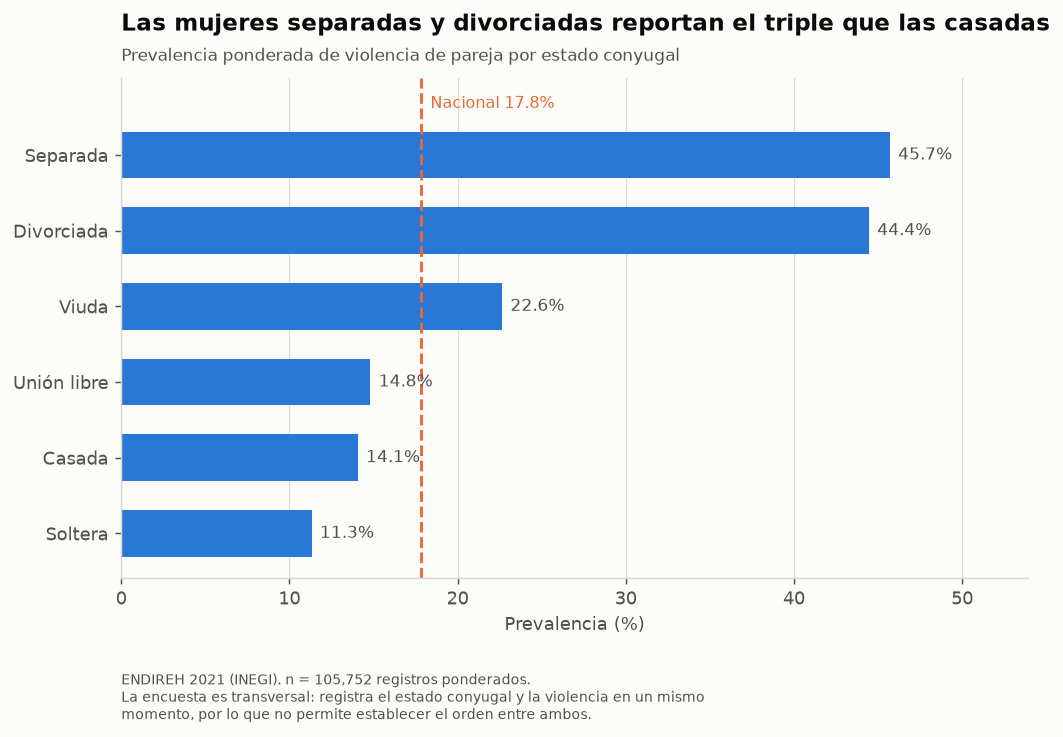

In [14]:
# figuras 3 y 4 ya generadas.
display(Image(filename=str(RUTA_FIGURAS / "03_prevalencia_por_entidad.png")))
display(Image(filename=str(RUTA_FIGURAS / "04_prevalencia_por_estado_civil.png")))

### 6.5 Efecto de la ponderación sobre `nivel_escolaridad`

Contrasta el peso de cada categoría en la muestra encuestada contra
el que tiene en la población estimada, y responde a: **por qué una medida simple y su versión ponderada no coinciden**.

La categoría A1 concentra el 58.6% de la muestra pero solo el 51.2% de la
población, siete puntos menos.  Por otro lado, C1 sube de 13.7% a 19.0%. La
muestra sobrerrepresenta a unas categorías y subrepresenta a otras, y el factor
de expansión corrige esa diferencia. Cualquier medida calculada sin ponderar
describe a las mujeres encuestadas; solo la ponderada estima el valor en la
población nacional.

Las categorías aparecen en su orden natural, A1 a C2, y no ordenadas por
frecuencia: al ser una variable ordinal, el orden forma parte de la
información. Su contenido no se interpreta, por lo indicado en la sección 3.

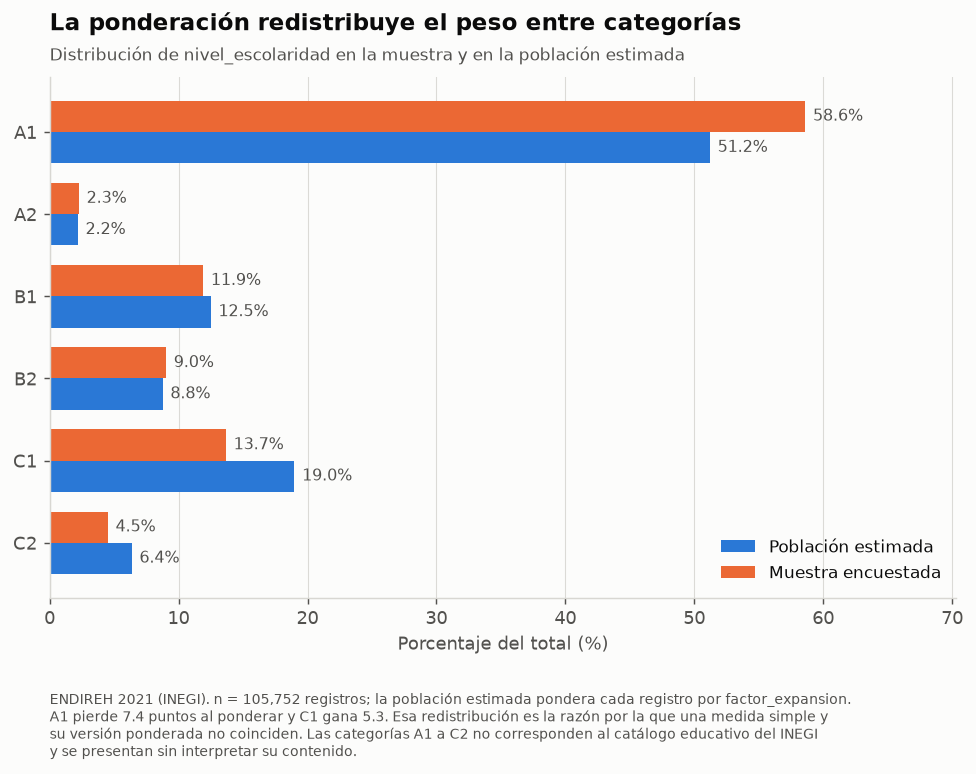

In [15]:
# figura 5 ya generada, leyéndola desde reports/figuras/.
display(Image(filename=str(RUTA_FIGURAS / "05_escolaridad_muestra_vs_poblacion.png")))

## 7. Hallazgos y limitaciones

### Hallazgos

1. **4,375 filas idénticas** (4.0% del total) y
   el encoding dañado desde el origen en 409 valores distintos.
2. **Los nulls son de tres naturalezas distintas** El 53.8% de nulos de `ingreso_pareja` es
   estructural y no admite imputación.
4. **La diferencia de ingreso entre grupos está en la cola superior**, no en el
   centro de la distribución.
5. **El estado conyugal discrimina mucho más que la geografía**: el rango entre
   estados conyugales (11.3% a 45.7%) triplica al rango entre entidades
   (11.2% a 23.0%).

### Limitaciones

1. **Tres variables tienen significado no confirmado**: `edad_primer_union`,
   `num_hijos` y `nivel_escolaridad`. Sus medidas se calculan y se reportan,
   pero su interpretación depende del mapeo de columnas.
2. **Las medidas de variabilidad no están ponderadas**, por lo indicado en la
   sección 5.
4. **La media de `edad_primer_union` es 10.03 en los tres grupos** —total, con
   violencia y sin violencia— idéntica hasta el segundo decimal, lo que sugiere
   que la variable no guarda relación con `sufrio_violencia_pareja`.
5. **Todo el análisis describe lo reportado en la ENDIREH**, no la ocurrencia
   real de la violencia. Una prevalencia baja puede reflejar menor ocurrencia o
   mayor silencio, y los datos no distinguen entre ambas.